# Pipeline #5: High-Value Donor Profiles

This notebook identifies donor characteristics associated with high-value status and predicts which donors are likely to become high-value in the next 12 months.


## Predictive and Explanatory Modeling Map

- **Explanatory track (why):** Logistic regression on an as-of label (top 20% by cumulative donor value at snapshot month `T`) to describe associations.
- **Predictive track (what next):** Classification models on a forward label (top 20% by value in `(T, T+12m]`) to rank donors for outreach.
- **Guardrail:** These are observational associations, not causal effects.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

## Problem Framing

**Business question:** What donor characteristics are associated with high-value donor status, and which current donors should the fundraising team prioritize for outreach to increase future high-value conversions?

**Stakeholders:** Fundraising manager, donor relations coordinators, and campaign planners.

**Target design (confirmed):**
- Explanatory label: donor is in the **top 20% by rank** of cumulative donor value as-of snapshot month `T` (ties broken in stable row order).
- Predictive label: donor is in the **top 20% by rank** of forward 12-month donor value `(T, T+12m]`.

**Primary KPI (confirmed):** Recall@TopK (with `K=15%` outreach capacity).

**Secondary metrics:** PR-AUC, Precision@TopK, ROC-AUC, F1, precision, recall.


### Plain-language metric guide

- Recall@TopK (primary): Of all donors who later become high-value, how many did we capture in our outreach list?
- Precision@TopK: Of donors in our outreach list, how many actually become high-value later?
- PR-AUC: Overall ranking quality when high-value donors are less common.
- ROC-AUC: General separation quality between likely high-value and not-high-value donors.
- F1: Single score that balances precision and recall.


## Data Acquisition, Preparation & Exploration


In [2]:
def resolve_data_dir() -> Path:
    candidates = [Path('data'), Path('../data'), Path('../../data'), Path.cwd() / 'data']
    for c in candidates:
        if c.exists() and (c / 'supporters.csv').exists():
            return c
    raise FileNotFoundError('Could not locate data directory containing supporters.csv')


DATA_DIR = resolve_data_dir()
print(f'Using data directory: {DATA_DIR.resolve()}\n')

# Load source tables
supporters = pd.read_csv(DATA_DIR / 'supporters.csv')
donations = pd.read_csv(DATA_DIR / 'donations.csv')
donation_allocations = pd.read_csv(DATA_DIR / 'donation_allocations.csv')

# Parse dates
supporters['created_at'] = pd.to_datetime(supporters['created_at'], errors='coerce')
donations['donation_date'] = pd.to_datetime(donations['donation_date'], errors='coerce')
donation_allocations['allocation_date'] = pd.to_datetime(donation_allocations['allocation_date'], errors='coerce')

# Keep only rows with valid donation dates for timeline modeling
donations = donations.dropna(subset=['donation_date']).copy()
donations['donation_month'] = donations['donation_date'].dt.to_period('M').dt.to_timestamp('M')

# Unified donation value (PHP-like value proxy)
donations['amount'] = pd.to_numeric(donations['amount'], errors='coerce')
donations['estimated_value'] = pd.to_numeric(donations['estimated_value'], errors='coerce')
donations['donation_value'] = donations['amount'].fillna(donations['estimated_value']).fillna(0)
donations['donation_value'] = donations['donation_value'].clip(lower=0)

print('supporters:', supporters.shape)
print('donations:', donations.shape)
print('donation_allocations:', donation_allocations.shape)
print('donation date range:', donations['donation_date'].min().date(), 'to', donations['donation_date'].max().date())

Using data directory: G:\My Drive\Winter 2026\IS 455 - Machine Learning (MK)\INTEX\data

supporters: (60, 15)
donations: (420, 15)
donation_allocations: (521, 7)
donation date range: 2023-01-09 to 2026-03-01


In [3]:
# Build month-end snapshot range with full 12-month forward window available
all_months = pd.date_range(
    donations['donation_month'].min(),
    donations['donation_month'].max(),
    freq='M'
)

max_snapshot_month = all_months.max() - pd.offsets.MonthEnd(12)
snapshot_months = all_months[all_months <= max_snapshot_month]

supporter_base = supporters[['supporter_id', 'supporter_type', 'relationship_type', 'region', 'country', 'acquisition_channel', 'created_at']].copy()
supporter_base['created_month'] = supporter_base['created_at'].dt.to_period('M').dt.to_timestamp('M')
supporter_base['created_month'] = supporter_base['created_month'].fillna(snapshot_months.min())

# Cross-join supporters x snapshot months, then keep only months after supporter creation
snap_df = pd.DataFrame({'snapshot_month': snapshot_months})
panel = supporter_base.assign(_k=1).merge(snap_df.assign(_k=1), on='_k', how='inner').drop(columns='_k')
panel = panel[panel['snapshot_month'] >= panel['created_month']].copy()

print('panel rows:', len(panel))
print('unique supporters in panel:', panel['supporter_id'].nunique())
print('snapshot months:', panel['snapshot_month'].min().date(), 'to', panel['snapshot_month'].max().date())

panel rows: 1620
unique supporters in panel: 60
snapshot months: 2023-01-31 to 2025-03-31


In [4]:
# Monthly donor aggregates
monthly = (
    donations
    .groupby(['supporter_id', 'donation_month'], as_index=False)
    .agg(
        monthly_donations=('donation_id', 'count'),
        monthly_value=('donation_value', 'sum'),
        monthly_monetary_value=('amount', 'sum'),
        monthly_recurring=('is_recurring', lambda s: pd.Series(s).fillna(False).astype(int).sum()),
        monthly_unique_channels=('channel_source', pd.Series.nunique),
        monthly_unique_campaigns=('campaign_name', lambda s: pd.Series(s).dropna().nunique()),
        monthly_monetary_count=('donation_type', lambda s: (pd.Series(s) == 'Monetary').sum()),
        monthly_inkind_count=('donation_type', lambda s: (pd.Series(s) == 'InKind').sum()),
        monthly_time_count=('donation_type', lambda s: (pd.Series(s) == 'Time').sum()),
        monthly_skills_count=('donation_type', lambda s: (pd.Series(s) == 'Skills').sum()),
        monthly_social_count=('donation_type', lambda s: (pd.Series(s) == 'SocialMedia').sum()),
    )
)

monthly_grid = panel[['supporter_id', 'snapshot_month']].rename(columns={'snapshot_month': 'donation_month'})
monthly = monthly_grid.merge(monthly, on=['supporter_id', 'donation_month'], how='left')

fill_zero_cols = [c for c in monthly.columns if c not in ['supporter_id', 'donation_month']]
monthly[fill_zero_cols] = monthly[fill_zero_cols].fillna(0)
monthly = monthly.sort_values(['supporter_id', 'donation_month']).reset_index(drop=True)

monthly.head()

,supporter_id,donation_month,monthly_donations,monthly_value,monthly_monetary_value,monthly_recurring,monthly_unique_channels,monthly_unique_campaigns,monthly_monetary_count,monthly_inkind_count,monthly_time_count,monthly_skills_count,monthly_social_count
0,1,2023-01-31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2023-02-28,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,2023-03-31,1.0,774.61,774.61,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1,2023-04-30,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,2023-05-31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Rolling / cumulative feature engineering (all as-of T)
for w in [3, 6, 12]:
    monthly[f'donations_{w}m'] = monthly.groupby('supporter_id')['monthly_donations'].transform(
        lambda s: s.rolling(w, min_periods=1).sum()
    )
    monthly[f'value_{w}m'] = monthly.groupby('supporter_id')['monthly_value'].transform(
        lambda s: s.rolling(w, min_periods=1).sum()
    )
    monthly[f'monetary_value_{w}m'] = monthly.groupby('supporter_id')['monthly_monetary_value'].transform(
        lambda s: s.rolling(w, min_periods=1).sum()
    )
    monthly[f'campaign_response_count_{w}m'] = monthly.groupby('supporter_id')['monthly_unique_campaigns'].transform(
        lambda s: s.rolling(w, min_periods=1).sum()
    )

monthly['cum_value_to_t'] = monthly.groupby('supporter_id')['monthly_value'].cumsum()
monthly['cum_donations_to_t'] = monthly.groupby('supporter_id')['monthly_donations'].cumsum()

# Average gift and recurring share over 12m
monthly['avg_gift_12m'] = np.where(monthly['donations_12m'] > 0, monthly['value_12m'] / monthly['donations_12m'], 0)
monthly['is_recurring_rate_12m'] = monthly.groupby('supporter_id')['monthly_recurring'].transform(lambda s: s.rolling(12, min_periods=1).sum())
monthly['is_recurring_rate_12m'] = np.where(monthly['donations_12m'] > 0, monthly['is_recurring_rate_12m'] / monthly['donations_12m'], 0)

# Donation mix shares over 12m
for src in ['monetary', 'inkind', 'time', 'skills', 'social']:
    monthly[f'{src}_share_12m'] = np.where(
        monthly['donations_12m'] > 0,
        monthly.groupby('supporter_id')[f'monthly_{src}_count'].transform(lambda s: s.rolling(12, min_periods=1).sum()) / monthly['donations_12m'],
        0,
    )

# Last donation timing (days since last donation at snapshot month)
monthly['had_donation_this_month'] = monthly['monthly_donations'] > 0
monthly['last_donation_month'] = monthly['donation_month'].where(monthly['had_donation_this_month'])
monthly['last_donation_month'] = monthly.groupby('supporter_id')['last_donation_month'].ffill()
monthly['days_since_last_donation'] = (monthly['donation_month'] - monthly['last_donation_month']).dt.days
monthly['days_since_last_donation'] = monthly['days_since_last_donation'].fillna(9999)

# Channel diversity proxy over 12m
monthly['channel_entropy_12m'] = monthly.groupby('supporter_id')['monthly_unique_channels'].transform(lambda s: s.rolling(12, min_periods=1).mean())

# Forward 12-month value (exclude current month)
fwd_parts = [monthly.groupby('supporter_id')['monthly_value'].shift(-k) for k in range(1, 13)]
monthly['forward_12m_value'] = pd.concat(fwd_parts, axis=1).sum(axis=1, min_count=1).fillna(0)

monthly.head()

,supporter_id,donation_month,monthly_donations,monthly_value,monthly_monetary_value,monthly_recurring,monthly_unique_channels,monthly_unique_campaigns,monthly_monetary_count,monthly_inkind_count,monthly_time_count,monthly_skills_count,monthly_social_count,donations_3m,value_3m,monetary_value_3m,campaign_response_count_3m,donations_6m,value_6m,monetary_value_6m,campaign_response_count_6m,donations_12m,value_12m,monetary_value_12m,campaign_response_count_12m,cum_value_to_t,cum_donations_to_t,avg_gift_12m,is_recurring_rate_12m,monetary_share_12m,inkind_share_12m,time_share_12m,skills_share_12m,social_share_12m,had_donation_this_month,last_donation_month,days_since_last_donation,channel_entropy_12m,forward_12m_value
0,1,2023-01-31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,False,NaT,9999.0,0.000000,6384.90
1,1,2023-02-28,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,False,NaT,9999.0,0.000000,6384.90
2,1,2023-03-31,1.0,774.61,774.61,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,774.61,774.61,0.0,1.0,774.61,774.61,0.0,1.0,774.61,774.61,0.0,774.61,1.0,774.61,1.0,1.0,0.0,0.0,0.0,0.0,True,2023-03-31,0.0,0.333333,5610.29
3,1,2023-04-30,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,774.61,774.61,0.0,1.0,774.61,774.61,0.0,1.0,774.61,774.61,0.0,774.61,1.0,774.61,1.0,1.0,0.0,0.0,0.0,0.0,False,2023-03-31,30.0,0.250000,5610.29
4,1,2023-05-31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,774.61,774.61,0.0,1.0,774.61,774.61,0.0,1.0,774.61,774.61,0.0,774.61,1.0,774.61,1.0,1.0,0.0,0.0,0.0,0.0,False,2023-03-31,61.0,0.200000,5610.29


In [6]:
# Allocation preference features (as-of T)
alloc = donation_allocations.copy()
alloc['allocation_month'] = alloc['allocation_date'].dt.to_period('M').dt.to_timestamp('M')
alloc['amount_allocated'] = pd.to_numeric(alloc['amount_allocated'], errors='coerce').fillna(0)

alloc_monthly = (
    donations[['donation_id', 'supporter_id']]
    .merge(alloc[['donation_id', 'allocation_month', 'program_area', 'amount_allocated']], on='donation_id', how='inner')
    .dropna(subset=['allocation_month'])
)

alloc_agg = (
    alloc_monthly.groupby(['supporter_id', 'allocation_month', 'program_area'], as_index=False)['amount_allocated'].sum()
)

alloc_pivot = alloc_agg.pivot_table(
    index=['supporter_id', 'allocation_month'],
    columns='program_area',
    values='amount_allocated',
    aggfunc='sum',
    fill_value=0,
).reset_index()
alloc_pivot.columns = [
    'supporter_id' if c == 'supporter_id' else ('allocation_month' if c == 'allocation_month' else f'alloc_{c}')
    for c in alloc_pivot.columns
]

alloc_grid = panel[['supporter_id', 'snapshot_month']].rename(columns={'snapshot_month': 'allocation_month'})
alloc_feat = alloc_grid.merge(alloc_pivot, on=['supporter_id', 'allocation_month'], how='left').fillna(0)
alloc_cols = [c for c in alloc_feat.columns if c.startswith('alloc_')]

for c in alloc_cols:
    alloc_feat[f'{c}_12m'] = alloc_feat.groupby('supporter_id')[c].transform(lambda s: s.rolling(12, min_periods=1).sum())

alloc_12m_cols = [c for c in alloc_feat.columns if c.endswith('_12m')]
alloc_feat['alloc_total_12m'] = alloc_feat[alloc_12m_cols].sum(axis=1)
alloc_feat['program_area_focus_ratio'] = np.where(
    alloc_feat['alloc_total_12m'] > 0,
    alloc_feat[alloc_12m_cols].max(axis=1) / alloc_feat['alloc_total_12m'],
    0,
)

alloc_out = alloc_feat[['supporter_id', 'allocation_month', 'program_area_focus_ratio', 'alloc_total_12m']]
alloc_out = alloc_out.rename(columns={'allocation_month': 'snapshot_month'})

In [7]:
# Final modeling table
model_df = panel.merge(
    monthly.rename(columns={'donation_month': 'snapshot_month'}),
    on=['supporter_id', 'snapshot_month'],
    how='left'
)
model_df = model_df.merge(alloc_out, on=['supporter_id', 'snapshot_month'], how='left')
model_df[['program_area_focus_ratio', 'alloc_total_12m']] = model_df[['program_area_focus_ratio', 'alloc_total_12m']].fillna(0)

# Tenure features
model_df['tenure_days'] = (model_df['snapshot_month'] - model_df['created_month']).dt.days.clip(lower=0)
model_df['tenure_months'] = np.floor(model_df['tenure_days'] / 30.4)

# Labels: exact top 20% within each snapshot month (rank-based; breaks ties by row order)
TOP_Q = 0.20

model_df['is_high_value_asof'] = model_df.groupby('snapshot_month')['cum_value_to_t'].transform(
    lambda s: (s.rank(method='first', ascending=False) <= max(1, int(np.ceil(TOP_Q * len(s))))).astype(int)
)
model_df['is_high_value_fwd'] = model_df.groupby('snapshot_month')['forward_12m_value'].transform(
    lambda s: (s.rank(method='first', ascending=False) <= max(1, int(np.ceil(TOP_Q * len(s))))).astype(int)
)

model_df['explanatory_cutoff_boundary'] = model_df.groupby('snapshot_month')['cum_value_to_t'].transform(
    lambda s: s.nlargest(max(1, int(np.ceil(TOP_Q * len(s))))).min()
)
model_df['predictive_cutoff_boundary'] = model_df.groupby('snapshot_month')['forward_12m_value'].transform(
    lambda s: s.nlargest(max(1, int(np.ceil(TOP_Q * len(s))))).min()
)

# Lightweight leakage checks
assert (model_df['snapshot_month'] <= max_snapshot_month).all(), 'Snapshot leakage: months beyond max allowed.'
assert model_df['forward_12m_value'].isna().sum() == 0, 'Forward label has missing values.'

print('Final modeling table:', model_df.shape)
print('Positive rate (as-of):', round(model_df['is_high_value_asof'].mean(), 3))
print('Positive rate (forward):', round(model_df['is_high_value_fwd'].mean(), 3))

Final modeling table: (1620, 54)
Positive rate (as-of): 0.2
Positive rate (forward): 0.2


### Feature Glossary (Generated Fields)

- `donations_3m`, `donations_6m`, `donations_12m`: donation counts in trailing 3/6/12 months up to snapshot `T`.
- `value_3m`, `value_12m`: total donation value in trailing windows up to `T`.
- `avg_gift_12m`: trailing 12-month average value per donation.
- `days_since_last_donation`: recency at `T`; large values indicate long inactivity.
- `is_recurring_rate_12m`: share of trailing 12-month donations marked recurring.
- `channel_entropy_12m`: average channel diversity signal over trailing 12 months.
- `campaign_response_count_12m`: campaign involvement count over trailing 12 months.
- `program_area_focus_ratio`: concentration of allocation preference in trailing 12 months (`max area share`).
- `is_high_value_asof`: explanatory label (top 20% by **rank** of cumulative value as-of `T`; ties broken by row order).
- `is_high_value_fwd`: predictive label (top 20% by **rank** of forward 12-month value `(T, T+12m]`).
- `predictive_cutoff_boundary`: smallest forward 12-month value that still lands in the monthly top cohort (diagnostic).
- `explanatory_cutoff_boundary`: same idea for cumulative value as-of `T` (diagnostic).


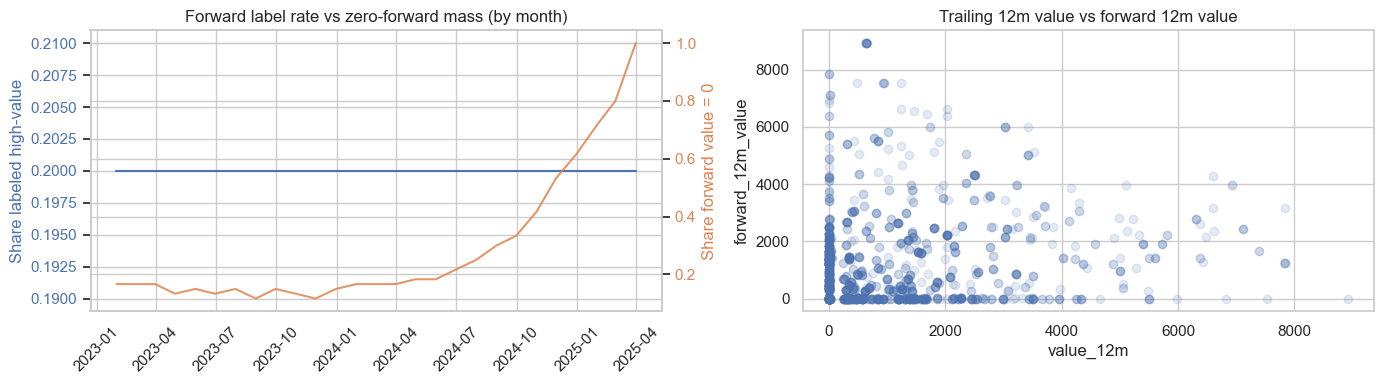

,snapshot_month,positive_rate,share_fwd_zero,implied_top20_fwd_floor,avg_value_12m,avg_days_since_last,avg_tenure_months
21,2024-10-31,0.2,0.416667,1792.57,1489.690000,799.983333,28.600000
22,2024-11-30,0.2,0.533333,1024.06,1590.901667,617.200000,29.600000
23,2024-12-31,0.2,0.616667,529.53,1518.993833,613.016667,30.600000
24,2025-01-31,0.2,0.716667,252.50,1519.509833,455.916667,31.600000
25,2025-02-28,0.2,0.800000,2.50,1526.524500,307.866667,32.400000
26,2025-03-31,0.2,1.000000,0.00,1621.940333,317.250000,33.483333


In [8]:
# Compact EDA readout + label diagnostics
eda = model_df.groupby('snapshot_month', as_index=False).agg(
    positive_rate=('is_high_value_fwd', 'mean'),
    share_fwd_zero=('forward_12m_value', lambda s: float((s == 0).mean())),
    implied_top20_fwd_floor=('predictive_cutoff_boundary', 'first'),
    avg_value_12m=('value_12m', 'mean'),
    avg_days_since_last=('days_since_last_donation', 'mean'),
    avg_tenure_months=('tenure_months', 'mean'),
)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(eda['snapshot_month'], eda['positive_rate'], color='C0', label='Forward high-value rate (~top 20%)')
ax[0].set_ylabel('Share labeled high-value', color='C0')
ax[0].tick_params(axis='y', labelcolor='C0')
ax[0].tick_params(axis='x', rotation=45)
ax0b = ax[0].twinx()
ax0b.plot(eda['snapshot_month'], eda['share_fwd_zero'], color='C1', alpha=0.85, label='Share with forward_12m_value = 0')
ax0b.set_ylabel('Share forward value = 0', color='C1')
ax0b.tick_params(axis='y', labelcolor='C1')
ax[0].set_title('Forward label rate vs zero-forward mass (by month)')

ax[1].scatter(model_df['value_12m'], model_df['forward_12m_value'], alpha=0.15)
ax[1].set_title('Trailing 12m value vs forward 12m value')
ax[1].set_xlabel('value_12m')
ax[1].set_ylabel('forward_12m_value')

plt.tight_layout()
plt.show()

display(eda.tail(6))

**What this means (plain language):** Rank-based top-20% labels keep about **20%** of donors flagged each month (by design). The orange line shows how many rows have **zero** forward-year giving; when that share is huge, an old >= 80th percentile rule can accidentally label almost everyone. The rank fix avoids that. The scatter still shows that stronger recent giving usually pairs with higher forward totals, which is why ranking models beat one-size rules.


## Modeling & Feature Selection


In [9]:
# Chronological split by snapshot month
months_sorted = np.array(sorted(model_df['snapshot_month'].unique()))
n_months = len(months_sorted)
train_end = int(n_months * 0.70)
valid_end = int(n_months * 0.85)

train_months = months_sorted[:train_end]
valid_months = months_sorted[train_end:valid_end]
test_months = months_sorted[valid_end:]

train_df = model_df[model_df['snapshot_month'].isin(train_months)].copy()
valid_df = model_df[model_df['snapshot_month'].isin(valid_months)].copy()
test_df = model_df[model_df['snapshot_month'].isin(test_months)].copy()

print('Months train/valid/test:', len(train_months), len(valid_months), len(test_months))
print('Rows train/valid/test:', len(train_df), len(valid_df), len(test_df))

Months train/valid/test: 18 4 5
Rows train/valid/test: 1080 240 300


In [10]:
feature_cols_num = [
    'tenure_months', 'days_since_last_donation',
    'donations_3m', 'donations_6m', 'donations_12m',
    'value_3m', 'value_12m', 'avg_gift_12m',
    'is_recurring_rate_12m', 'channel_entropy_12m',
    'campaign_response_count_12m', 'program_area_focus_ratio', 'alloc_total_12m',
    'monetary_share_12m', 'inkind_share_12m', 'time_share_12m', 'skills_share_12m', 'social_share_12m',
]
feature_cols_cat = ['supporter_type', 'relationship_type', 'region', 'country', 'acquisition_channel']
feature_cols = feature_cols_num + feature_cols_cat

X_train = train_df[feature_cols]
X_valid = valid_df[feature_cols]
X_test = test_df[feature_cols]

y_train = train_df['is_high_value_fwd']
y_valid = valid_df['is_high_value_fwd']
y_test = test_df['is_high_value_fwd']

preprocess_logit = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), feature_cols_num),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), feature_cols_cat),
    ]
)

preprocess_tree = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), feature_cols_num),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), feature_cols_cat),
    ]
)

### Feature selection (Ch. 16 — what we include and skip)

**Included (leakage-safe, as-of `T`):** supporter profile fields (`supporter_type`, `relationship_type`, region, channel), **RFM-style** counts and values over 3/6/12 months, recency (`days_since_last_donation`), recurring share, donation **mix** shares, **campaign** participation, and **allocation** concentration (`program_area_focus_ratio`, `alloc_total_12m`).

**Excluded on purpose:** raw IDs as predictors, free-text fields, social post-hoc attribution metrics (for example `donation_referrals` / attributed revenue), any **future-window** donation amounts, and unused high-cardinality buckets.

**Process note:** We compared models on a domain-vetted feature set; optional next steps are backward elimination or stability checks across time splits.

In [11]:
def topk_metrics(y_true, y_score, k_frac=0.15):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    n = len(y_true)
    k = max(1, int(np.ceil(n * k_frac)))
    idx = np.argsort(-y_score)[:k]
    recall_k = y_true[idx].sum() / max(1, y_true.sum())
    precision_k = y_true[idx].mean() if k > 0 else 0
    return recall_k, precision_k, k

def evaluate_scores(y_true, y_score, threshold=0.5, k_frac=0.15):
    y_pred = (y_score >= threshold).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    pr_auc = average_precision_score(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)
    recall_k, precision_k, k = topk_metrics(y_true, y_score, k_frac=k_frac)
    return {
        'PR_AUC': pr_auc,
        'ROC_AUC': roc_auc,
        'Precision': p,
        'Recall': r,
        'F1': f1,
        'Recall@TopK': recall_k,
        'Precision@TopK': precision_k,
        'K_count': k,
    }

In [12]:
# Predictive candidates
logit_pred = Pipeline([
    ('prep', preprocess_logit),
    ('model', LogisticRegression(max_iter=1500, class_weight='balanced', C=1.0, random_state=42))
])

rf_pred = Pipeline([
    ('prep', preprocess_tree),
    ('model', RandomForestClassifier(
        n_estimators=400,
        max_depth=10,
        min_samples_leaf=20,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1,
    ))
])

candidates = {
    'Logistic (predictive baseline)': logit_pred,
    'RandomForest (predictive)': rf_pred,
}

rows = []
valid_scores = {}
for name, model in candidates.items():
    model.fit(X_train, y_train)
    s_valid = model.predict_proba(X_valid)[:, 1]
    valid_scores[name] = s_valid
    m = evaluate_scores(y_valid, s_valid, threshold=0.5, k_frac=0.15)
    m['Model'] = name
    rows.append(m)

valid_results = pd.DataFrame(rows)[['Model', 'PR_AUC', 'Recall@TopK', 'Precision@TopK', 'ROC_AUC', 'F1', 'Precision', 'Recall']].sort_values(['PR_AUC', 'Recall@TopK'], ascending=False)
display(valid_results)

best_model_name = valid_results.iloc[0]['Model']
print('Selected predictive model:', best_model_name)

,Model,PR_AUC,Recall@TopK,Precision@TopK,ROC_AUC,F1,Precision,Recall
0,Logistic (predictive baseline),0.474736,0.354167,0.472222,0.780056,0.532258,0.434211,0.687500
1,RandomForest (predictive),0.470796,0.354167,0.472222,0.798177,0.530303,0.416667,0.729167


Selected predictive model: Logistic (predictive baseline)


In [13]:
# Threshold sweep on validation set for selected model
best_model = candidates[best_model_name]
val_scores = valid_scores[best_model_name]

# PR-AUC and Top-K metrics depend only on score ranking, not on probability threshold
ranking_snapshot = evaluate_scores(y_valid, val_scores, threshold=0.5, k_frac=0.15)
ranking_tbl = pd.DataFrame([{k: ranking_snapshot[k] for k in ['PR_AUC', 'ROC_AUC', 'Recall@TopK', 'Precision@TopK', 'K_count']}])
print('Ranking / capacity metrics (same for every row in the threshold grid below):')
display(ranking_tbl)

threshold_grid = np.arange(0.20, 0.81, 0.05)
rows = []
for t in threshold_grid:
    y_pred = (val_scores >= t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_valid, y_pred, average='binary', zero_division=0)
    rows.append({'threshold': round(float(t), 2), 'Precision': p, 'Recall': r, 'F1': f1})

thresh_df = pd.DataFrame(rows)
print('Threshold grid (Precision / Recall / F1 only):')
display(thresh_df)

# Operationally choose threshold that maximizes Recall on validation among reasonable precision floor
cand = thresh_df[thresh_df['Precision'] >= 0.20]
if len(cand) == 0:
    operating_threshold = 0.5
else:
    operating_threshold = float(cand.sort_values('Recall', ascending=False).iloc[0]['threshold'])
print('Operating threshold selected:', operating_threshold)

Ranking / capacity metrics (same for every row in the threshold grid below):


,PR_AUC,ROC_AUC,Recall@TopK,Precision@TopK,K_count
0,0.474736,0.780056,0.354167,0.472222,36


Threshold grid (Precision / Recall / F1 only):


,threshold,Precision,Recall,F1
0,0.20,0.286713,0.854167,0.429319
1,0.25,0.312977,0.854167,0.458101
2,0.30,0.338843,0.854167,0.485207
3,0.35,0.360360,0.833333,0.503145
4,0.40,0.400000,0.791667,0.531469
5,0.45,0.406977,0.729167,0.522388
6,0.50,0.434211,0.687500,0.532258
7,0.55,0.483333,0.604167,0.537037
8,0.60,0.480000,0.500000,0.489796
9,0.65,0.468085,0.458333,0.463158


Operating threshold selected: 0.2


In [14]:
# Final predictive evaluation on test (refit on train+valid)
train_valid_df = pd.concat([train_df, valid_df], axis=0)
X_train_valid = train_valid_df[feature_cols]
y_train_valid = train_valid_df['is_high_value_fwd']

best_model.fit(X_train_valid, y_train_valid)
test_scores = best_model.predict_proba(X_test)[:, 1]
test_metrics = evaluate_scores(y_test, test_scores, threshold=operating_threshold, k_frac=0.15)

display(pd.DataFrame([test_metrics]))

cm = confusion_matrix(y_test, (test_scores >= operating_threshold).astype(int))
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Pred 0', 'Pred 1'])
display(cm_df)

print(classification_report(y_test, (test_scores >= operating_threshold).astype(int), zero_division=0))

,PR_AUC,ROC_AUC,Precision,Recall,F1,Recall@TopK,Precision@TopK,K_count
0,0.324983,0.635243,0.251572,0.666667,0.365297,0.216667,0.288889,45


,Pred 0,Pred 1
Actual 0,121,119
Actual 1,20,40


              precision    recall  f1-score   support

           0       0.86      0.50      0.64       240
           1       0.25      0.67      0.37        60

    accuracy                           0.54       300
   macro avg       0.55      0.59      0.50       300
weighted avg       0.74      0.54      0.58       300



In [15]:
# Explanatory model on as-of target (train+valid), interpreted as association
X_exp = train_valid_df[feature_cols]
y_exp = train_valid_df['is_high_value_asof']

exp_model = Pipeline([
    ('prep', preprocess_logit),
    ('model', LogisticRegression(max_iter=1500, class_weight='balanced', C=1.0, random_state=42))
])
exp_model.fit(X_exp, y_exp)

prep = exp_model.named_steps['prep']
mdl = exp_model.named_steps['model']
feature_names = prep.get_feature_names_out()
coef = mdl.coef_.ravel()
odds = np.exp(coef)

coef_df = pd.DataFrame({'feature': feature_names, 'coef': coef, 'odds_ratio': odds})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_top = coef_df.sort_values('abs_coef', ascending=False).head(15)
display(coef_top[['feature', 'coef', 'odds_ratio']])

,feature,coef,odds_ratio
9,num__channel_entropy_12m,3.345366,28.370955
30,cat__country_Canada,2.159725,8.668754
33,cat__country_USA,-1.739383,0.175629
6,num__value_12m,1.493170,4.451181
37,cat__acquisition_channel_SocialMedia,1.272406,3.569430
4,num__donations_12m,-1.265710,0.282039
19,cat__supporter_type_MonetaryDonor,-1.130875,0.322751
35,cat__acquisition_channel_Event,-0.976302,0.376702
5,num__value_3m,0.951348,2.589197
39,cat__acquisition_channel_WordOfMouth,0.929927,2.534323


### Note on p-values (explanatory track)

`sklearn.linear_model.LogisticRegression` does **not** output p-values or confidence intervals. We interpret **sign**, **magnitude**, and **odds ratios** as **associational** evidence only. Use **statsmodels** or bootstrap CIs if you need classical inference.

**Modeling readout (plain language):** We choose the predictive model based on out-of-sample ranking quality, and we use explanatory logistic coefficients to describe which donor patterns are most strongly associated with high-value status today.


## Evaluation & Interpretation


In [16]:
# Business-facing operating summary
summary = pd.DataFrame([
    {
        'KPI': 'Recall@TopK (primary)',
        'Value': round(float(test_metrics['Recall@TopK']), 3),
        'Interpretation': 'Share of truly high-value future donors captured in the top 15% outreach list.'
    },
    {
        'KPI': 'Precision@TopK (secondary)',
        'Value': round(float(test_metrics['Precision@TopK']), 3),
        'Interpretation': 'Hit-rate inside the top 15% outreach list.'
    },
    {
        'KPI': 'PR-AUC (secondary)',
        'Value': round(float(test_metrics['PR_AUC']), 3),
        'Interpretation': 'Overall ability to rank positives ahead of negatives under class imbalance.'
    },
])

display(summary)

,KPI,Value,Interpretation
0,Recall@TopK (primary),0.217,Share of truly high-value future donors captur...
1,Precision@TopK (secondary),0.289,Hit-rate inside the top 15% outreach list.
2,PR-AUC (secondary),0.325,Overall ability to rank positives ahead of neg...


### False positives vs false negatives (fundraising impact)

- **False positive:** We over-prioritize a donor who does **not** become forward high-value. **Cost:** wasted staff time, donor fatigue, less capacity for true high-potential supporters.
- **False negative:** We **miss** a donor who **would** become high-value. **Cost:** lost revenue and a weaker major-donor pipeline.

**Why Recall@TopK is primary:** With capped outreach, we first want the ranked list to **cover** future high-value donors; tighten **K** or thresholds if precision becomes too low.

**What this means for operations:** Use model scores as a ranked queue. If staff can only contact a limited number of donors each month, start with the top 15% by score. This strategy optimizes coverage of future high-value donors under real staffing limits.


## Causal and Relationship Analysis

- This notebook uses observational data, so findings are **associational**, not causal.
- Coefficients/odds ratios show patterns linked with high-value status, but they do not prove that changing one feature will cause donor value to change.
- Potential confounders include campaign strategy shifts, macroeconomic conditions, and manual donor stewardship differences not fully recorded in the tables.
- Stronger causal claims would require quasi-experiments or randomized outreach designs.


**How to read this section:** Treat coefficient directions as relationship signals (associated with higher/lower high-value odds), not proof that changing one feature will cause a donor outcome change.


In [17]:
# Translate top explanatory features into plain-language notes
def readable_feature(name):
    return name.replace('num__', '').replace('cat__', '')

coef_top_readable = coef_top[['feature', 'odds_ratio']].copy()
coef_top_readable['feature'] = coef_top_readable['feature'].map(readable_feature)
coef_top_readable['association_direction'] = np.where(coef_top_readable['odds_ratio'] >= 1, 'Positive association', 'Negative association')
display(coef_top_readable.head(12))

,feature,odds_ratio,association_direction
9,channel_entropy_12m,28.370955,Positive association
30,country_Canada,8.668754,Positive association
33,country_USA,0.175629,Negative association
6,value_12m,4.451181,Positive association
37,acquisition_channel_SocialMedia,3.569430,Positive association
4,donations_12m,0.282039,Negative association
19,supporter_type_MonetaryDonor,0.322751,Negative association
35,acquisition_channel_Event,0.376702,Negative association
5,value_3m,2.589197,Positive association
39,acquisition_channel_WordOfMouth,2.534323,Positive association


## Deployment Notes

- Score donors monthly after month-end data refresh.
- Publish a ranked table to the fundraising dashboard with recommended action tier.
- Store model version, score date, threshold, and top-K policy for auditability.
- Monitor drift monthly and recalibrate quarterly.

**Rubric / integration:** Wire monthly ranked scores and tiers into the INTEX **web app** (donor dashboard, API, or batch export) so the pipeline is not notebook-only.


**Simple operating rule:** Refresh scores monthly, contact the top 15% first, track Recall@TopK as the main success measure, and adjust threshold quarterly if team capacity changes.


### Playbook KPI glossary

- `Recall@TopK`: percent of future high-value donors captured in the outreach list.
- `Precision@TopK`: percent of outreach list that truly becomes high-value.
- `Conversion lift`: improvement in high-value conversion relative to business-as-usual outreach.
- `Follow-through rate`: percent of assigned donor actions completed by staff.


In [18]:
# Action Playbook output
scored_test = test_df[['supporter_id', 'snapshot_month']].copy()
scored_test['score'] = test_scores

# Tier by score bands
scored_test['tier'] = pd.cut(
    scored_test['score'],
    bins=[-np.inf, np.quantile(scored_test['score'], 0.70), np.quantile(scored_test['score'], 0.90), np.inf],
    labels=['Routine', 'Watch', 'High Priority']
)

playbook = pd.DataFrame([
    {
        'Tier/Question': 'High Priority',
        'Rule': 'Top ~10% model scores',
        'Action': 'Assign personalized call + impact report + tailored ask within 7 days.',
        'Channel/Owner': 'Donor Relations Lead',
        'KPI': 'Recall@TopK (primary) + conversion lift'
    },
    {
        'Tier/Question': 'Watch',
        'Rule': 'Next ~20% model scores',
        'Action': 'Send targeted stewardship email and follow-up call if no response in 14 days.',
        'Channel/Owner': 'Fundraising Coordinator',
        'KPI': 'Precision@TopK + response rate'
    },
    {
        'Tier/Question': 'Routine',
        'Rule': 'Remaining donor pool',
        'Action': 'Keep regular monthly nurture cadence and monitor score trend.',
        'Channel/Owner': 'Automation + Team Oversight',
        'KPI': 'Follow-through rate + long-term upgrade rate'
    },
])

display(playbook)

score_tier_summary = scored_test.groupby('tier', as_index=False).agg(donors=('supporter_id', 'count'), avg_score=('score', 'mean'))
display(score_tier_summary)

,Tier/Question,Rule,Action,Channel/Owner,KPI
0,High Priority,Top ~10% model scores,Assign personalized call + impact report + tai...,Donor Relations Lead,Recall@TopK (primary) + conversion lift
1,Watch,Next ~20% model scores,Send targeted stewardship email and follow-up ...,Fundraising Coordinator,Precision@TopK + response rate
2,Routine,Remaining donor pool,Keep regular monthly nurture cadence and monit...,Automation + Team Oversight,Follow-through rate + long-term upgrade rate


,tier,donors,avg_score
0,Routine,210,0.173226
1,Watch,60,0.634138
2,High Priority,30,0.839272


### Synthesis (predictive vs explanatory)

- **Where they agree:** Recency, frequency, and sustained donation behavior are key in both tracks.
- **Where they differ:** The predictive model captures nonlinear interactions for ranking performance, while the explanatory model provides clearer directional association narratives.
- **How to use together:** Use predictive scores for monthly prioritization and explanatory findings for campaign strategy and stakeholder communication.
- **Limitation reminder:** These findings support better decisions, but they do not prove causal effects.


## 6. Deployment Notes (Safe Harbor — live integration)

**Architecture:** Shared feature code in `ml_service/`; inference in `ml_api/` (FastAPI); .NET `backend/backend/Controllers/MlController.cs` proxies requests using `Ml:BaseUrl` and optional `Ml:ApiKey` (header `X-ML-API-Key`).

**Health / audit:** GET /api/Ml/deployment-status and staff page /admin/ml-integration.

**Docs & env:** See docs/ml-deployment.md and docs/SETUP.md (ML section).

**Retrain from CSVs:** Use scripts/train_*.py where present; notebooks stay executable against repo data/.

**This pipeline:** Placeholder FastAPI POST /predict/donor-high-value when models/donor_high_value_rf.joblib exists. **UI:** /donors (additive section when wired).
